# Clinical Data Intelligence — Tabular EDA Module
### Heart Disease (UCI Cleveland) + Heart Failure Clinical Records

This notebook is the **exploratory data analysis stage** of the Clinical Data Intelligence & Monitoring System. Rather than a one-off script, it is structured as a **reusable EDA toolkit** (Section 1) that is then applied to each tabular dataset in the project — so `cardio_train`, `heart_disease`, `heart_failure`, and later the MS dataset all get the same rigor.

EDA here must answer four questions for every dataset before any modelling (LogReg / RF / XGBoost / LightGBM / anomaly detection):

1. **Structure** — grain, shape, types.
2. **Quality** — missing values (*including disguised missing codes*), duplicates, impossible clinical values.
3. **Distributions** — shape and skew of each variable; class balance of the target.
4. **Signal & risk** — association with the target, multicollinearity, and **data-leakage hazards**.

| Dataset | File | Rows × Cols | Target | Task |
|---|---|---|---|---|
| Heart Disease | `heart_disease.csv` | 303 × 14 | `target` (1 = disease) | classification |
| Heart Failure | `heart_failure_clinical_records_dataset.csv` | 299 × 13 | `DEATH_EVENT` (1 = died) | classification / risk |


## 1. Setup, robust paths, and the reusable EDA toolkit

### 1.1 Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

### 1.2 Path resolution

The repo stores data under `data/raw/`. Notebooks are often run from a different working directory (e.g. `notebooks/`), which is the usual cause of *"file not found"*. `data_path()` searches the common locations and, failing that, raises an error that tells you exactly where it looked — set `DATA_DIR_OVERRIDE` to an absolute path to bypass all of it.

In [2]:
DATA_DIR_OVERRIDE = None   # e.g. "/home/me/project/data/raw"

def find_data_dir():
    if DATA_DIR_OVERRIDE:
        return Path(DATA_DIR_OVERRIDE)
    for c in [Path("data/raw"), Path("../data/raw"),
              Path("../../data/raw"), Path(".")]:
        if c.exists():
            return c.resolve()
    return Path(".").resolve()

DATA_DIR = find_data_dir()

def data_path(filename):
    p = DATA_DIR / filename
    if not p.exists():
        raise FileNotFoundError(
            f"Could not find {filename!r} in {DATA_DIR}.\n"
            f"cwd = {Path.cwd()}\n"
            f"Set DATA_DIR_OVERRIDE to the absolute path of your data/raw folder."
        )
    return p

print("Resolved DATA_DIR:", DATA_DIR)

Resolved DATA_DIR: /Users/cosmina/Ginger_Gradient/clinical-intelligence-system/data/raw


### 1.3 The toolkit

Six small functions cover the repeatable parts of EDA. Each takes a DataFrame so the same code runs on every dataset.

In [3]:
def load_csv(filename):
    """Read a CSV and strip the UTF-8 BOM that some exports leave on the first header."""
    df = pd.read_csv(data_path(filename))
    df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]
    return df


def profile(df, name=""):
    """One-glance structural + quality summary."""
    print(f"=== {name} ===")
    print(f"shape           : {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"duplicate rows  : {df.duplicated().sum()}")
    print(f"missing (NaN)   : {int(df.isna().sum().sum())}")
    print(f"memory          : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    dtypes = df.dtypes.value_counts()
    print("dtypes          :", {str(k): int(v) for k, v in dtypes.items()})


def missing_codes(df, code_map):
    """Disguised-missing detector. code_map = {col: [bad_value, ...]}.
    Returns counts; does NOT modify df."""
    rows = []
    for col, bad in code_map.items():
        n = df[col].isin(bad).sum()
        rows.append({"column": col, "missing_code(s)": bad, "rows_affected": int(n)})
    return pd.DataFrame(rows)


def plot_distributions(df, cols, ncols=3, title=""):
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    for ax, col in zip(np.ravel(axes), cols):
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f"{col}  (skew={df[col].skew():+.2f})")
    for ax in np.ravel(axes)[len(cols):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


def target_analysis(df, target, cont_cols, cat_cols):
    """Boxplots of continuous features by target, and event-rate bars for categoricals."""
    base_rate = df[target].mean()
    print(f"Target '{target}' positive rate: {base_rate:.1%}")

    fig, axes = plt.subplots(int(np.ceil(len(cont_cols) / 3)), 3,
                             figsize=(15, 3.5 * np.ceil(len(cont_cols) / 3)))
    for ax, col in zip(np.ravel(axes), cont_cols):
        sns.boxplot(x=target, y=col, data=df, ax=ax)
        ax.set_title(f"{col} by {target}")
    for ax in np.ravel(axes)[len(cont_cols):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(int(np.ceil(len(cat_cols) / 3)), 3,
                             figsize=(15, 3.5 * np.ceil(len(cat_cols) / 3)))
    for ax, col in zip(np.ravel(axes), cat_cols):
        df.groupby(col)[target].mean().plot(kind="bar", ax=ax)
        ax.axhline(base_rate, ls="--", color="k", lw=1)
        ax.set_title(f"{target} rate by {col}"); ax.set_ylabel(f"P({target}=1)")
    for ax in np.ravel(axes)[len(cat_cols):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()


def corr_heatmap(df, title=""):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(min(1 + 0.7 * len(corr), 12), min(1 + 0.6 * len(corr), 10)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
                cbar_kws={"shrink": .8})
    plt.title(title); plt.show()
    return corr

## 2. Heart Disease (UCI Cleveland)

A diagnostic dataset: each row is one patient with `target = 1` indicating presence of heart disease.

In [4]:
hd = load_csv("heart_disease.csv")
profile(hd, "heart_disease")
hd.head()

=== heart_disease ===
shape           : 303 rows x 14 cols
duplicate rows  : 1
missing (NaN)   : 0
memory          : 33.3 KB
dtypes          : {'int64': 13, 'float64': 1}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 2.1 Data dictionary

Most columns are coded integers. Keep the numeric columns for modelling and add readable labels only for plotting.

| col | meaning |
|---|---|
| `sex` | 1 = male, 0 = female |
| `cp` | chest pain: 0 typical angina · 1 atypical · 2 non-anginal · 3 asymptomatic |
| `trestbps` | resting blood pressure (mmHg) |
| `chol` | serum cholesterol (mg/dl) |
| `fbs` | fasting blood sugar > 120 mg/dl (1/0) |
| `restecg` | resting ECG: 0 normal · 1 ST-T abnormality · 2 LV hypertrophy |
| `thalach` | max heart rate achieved |
| `exang` | exercise-induced angina (1/0) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | ST slope: 0 up · 1 flat · 2 down |
| `ca` | major vessels colored (0–3); **4 = missing** |
| `thal` | 1 normal · 2 fixed defect · 3 reversible defect; **0 = missing** |
| `target` | 1 = disease, 0 = no disease |


In [5]:
hd.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 2.2 Quality: duplicates and *disguised* missing values

The naive `isna()` count is 0, but two columns use sentinel codes for missing. This is the classic UCI trap — treat `ca == 4` and `thal == 0` as missing, not as real categories.

In [6]:
print("Disguised-missing scan:")
display(missing_codes(hd, {"ca": [4], "thal": [0]}))
print("Exact duplicate rows:", hd.duplicated().sum())

Disguised-missing scan:


,column,missing_code(s),rows_affected
0,ca,[4],5
1,thal,[0],2


Exact duplicate rows: 1


In [7]:
hd_clean = hd.drop_duplicates().copy()
hd_clean["ca"]   = hd_clean["ca"].replace(4, np.nan)
hd_clean["thal"] = hd_clean["thal"].replace(0, np.nan)

# Simple, defensible imputation for a handful of cells: mode of the column.
for col in ["ca", "thal"]:
    hd_clean[col] = hd_clean[col].fillna(hd_clean[col].mode()[0])

print("After cleaning:", hd_clean.shape, "| NaNs:", int(hd_clean.isna().sum().sum()))

After cleaning: (302, 14) | NaNs: 0


### 2.3 Clinical sanity checks

Flag physiologically impossible values. (`chol = 0` would be impossible and is a known issue in *other* versions of this data — worth checking explicitly.)

In [8]:
checks = {
    "trestbps out of 80-200": (~hd_clean["trestbps"].between(80, 200)).sum(),
    "chol out of 100-600"    : (~hd_clean["chol"].between(100, 600)).sum(),
    "chol == 0 (impossible)" : (hd_clean["chol"] == 0).sum(),
    "thalach out of 60-220"  : (~hd_clean["thalach"].between(60, 220)).sum(),
}
for k, v in checks.items():
    print(f"{k:26s}: {v}")

trestbps out of 80-200    : 0
chol out of 100-600       : 0
chol == 0 (impossible)    : 0
thalach out of 60-220     : 0


### 2.4 Distributions and target signal

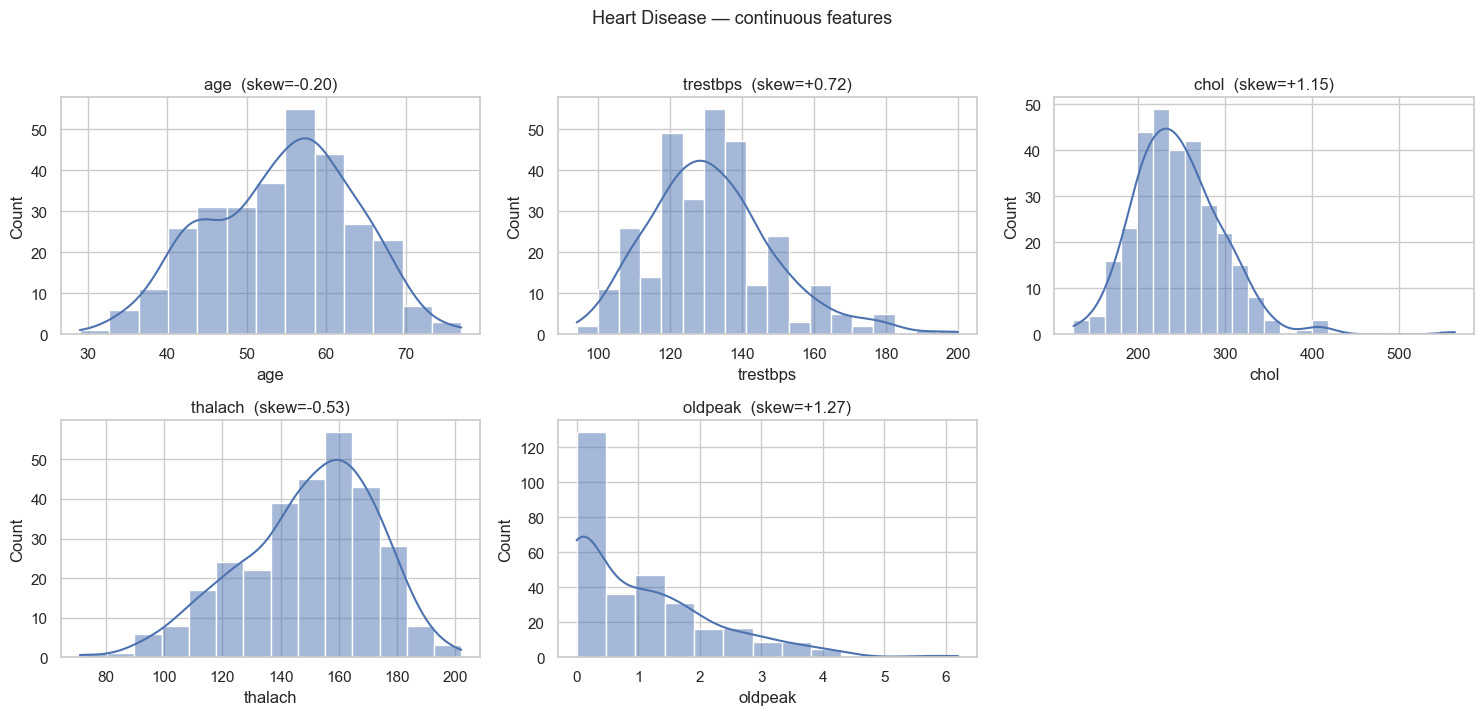

In [9]:
hd_cont = ["age", "trestbps", "chol", "thalach", "oldpeak"]
hd_cat  = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
plot_distributions(hd_clean, hd_cont, title="Heart Disease — continuous features")

Target 'target' positive rate: 54.3%


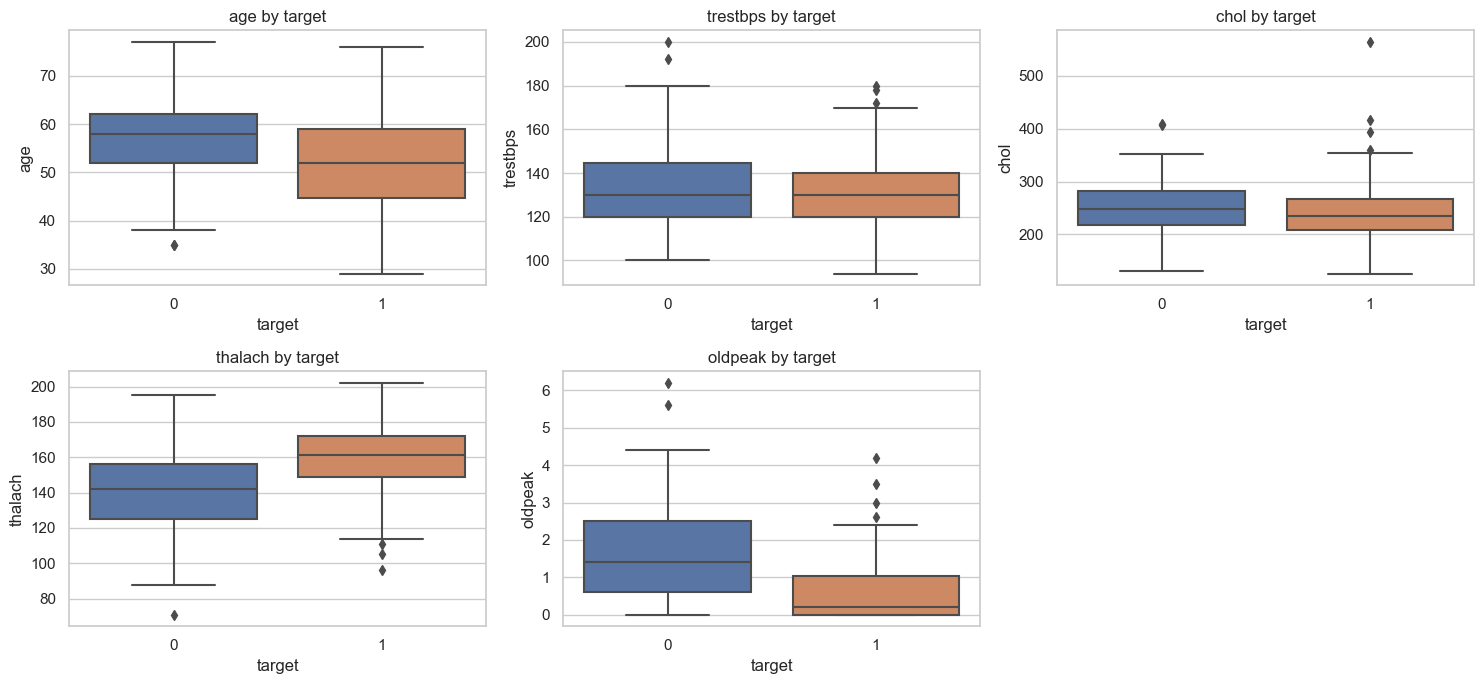

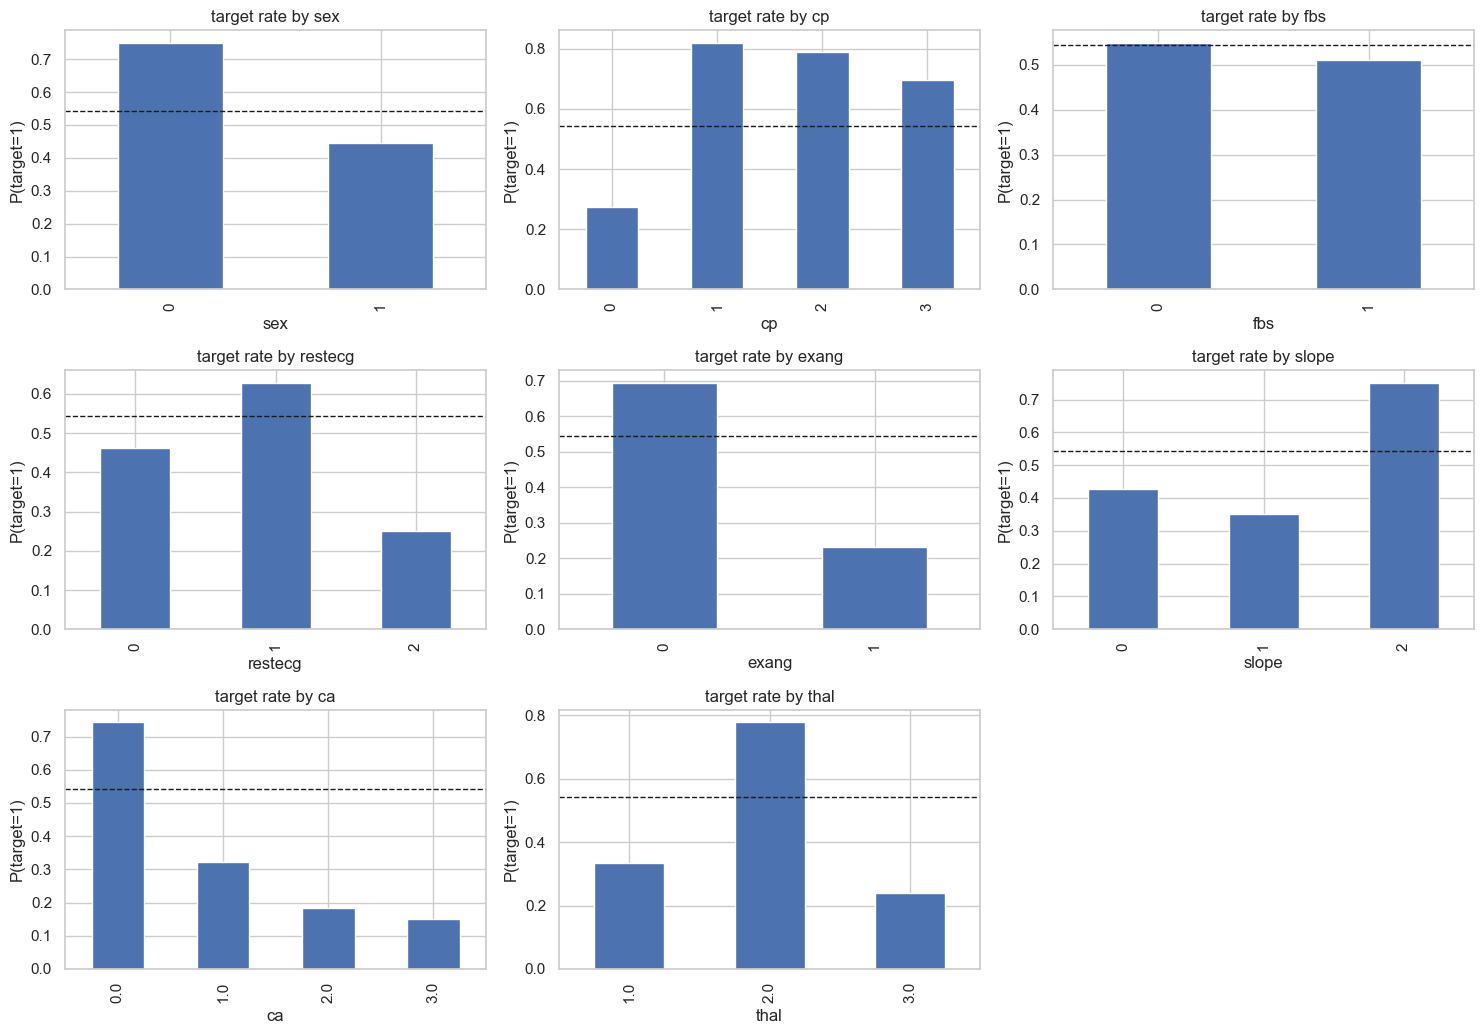

In [10]:
target_analysis(hd_clean, "target", hd_cont, hd_cat)

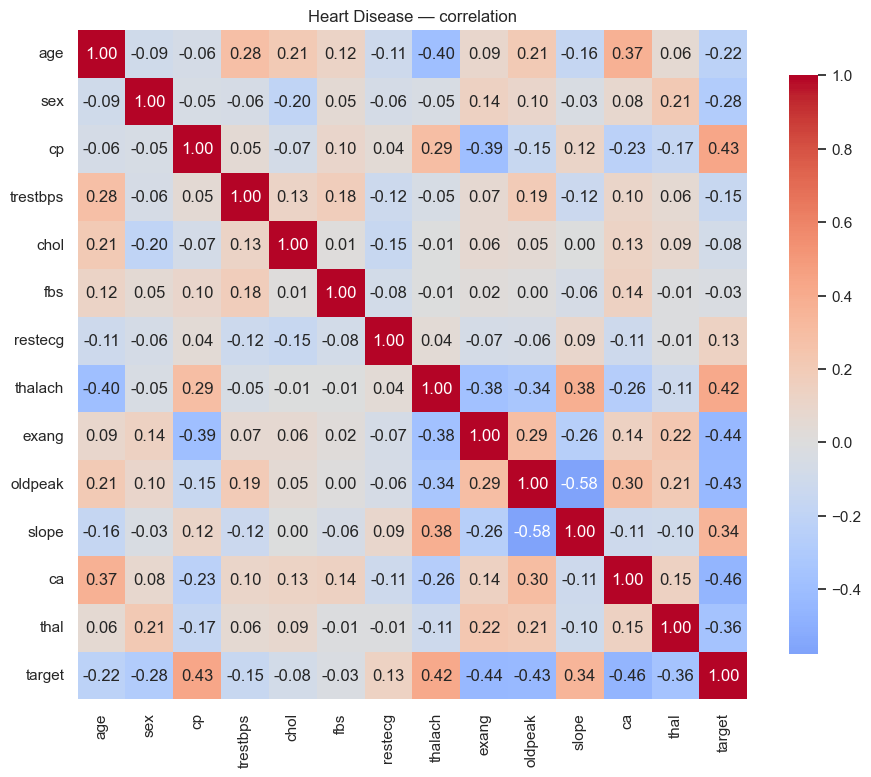

cp          0.432
thalach     0.420
slope       0.344
restecg     0.135
fbs        -0.027
chol       -0.081
trestbps   -0.146
age        -0.221
sex        -0.284
thal       -0.362
oldpeak    -0.429
exang      -0.436
ca         -0.464


In [11]:
hd_corr = corr_heatmap(hd_clean, "Heart Disease — correlation")
print(hd_corr["target"].drop("target").sort_values(ascending=False).round(3).to_string())

Expect `cp`, `thalach`, and `slope` to associate positively with disease, and `oldpeak`, `exang`, `ca` negatively/positively depending on coding — all consistent with cardiology.

### 2.5 Bridge to modelling — leakage-safe imputation

In 2.2 we imputed `ca` / `thal` on the *full* dataset, which is fine for **looking** at the data. For **modelling** it is a subtle leak: the fill value (the mode) is computed using rows that later land in the test fold. The fix is to push the sentinel-cleaning and imputation **inside an sklearn `Pipeline`**, so they are re-fitted on the training rows of each CV fold only. This is the pattern every downstream model (LogReg / RF / XGBoost / LightGBM) should sit on.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Start from the RAW frame (only de-duplicated) and let the PIPELINE do all cleaning,
# so nothing is fit on data outside the training fold.
hd_raw = hd.drop_duplicates().reset_index(drop=True)
X = hd_raw.drop(columns="target")
y = hd_raw["target"]

# Step 1 (stateless): sentinel codes -> NaN. Safe anywhere because it learns nothing.
def sentinels_to_nan(df):
    df = df.copy()
    df["ca"]   = df["ca"].replace(4, np.nan)
    df["thal"] = df["thal"].replace(0, np.nan)
    return df

to_nan = FunctionTransformer(sentinels_to_nan)

# Step 2 (stateful): impute + scale, fit on the training fold only.
prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("scale", StandardScaler())]), X.columns.tolist())
])

clf = Pipeline([("to_nan", to_nan), ("prep", prep),
                ("model", LogisticRegression(max_iter=1000))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc = cross_val_score(clf, X, y, cv=cv, scoring="roc_auc")
print(f"Leakage-safe baseline LogReg ROC-AUC: {auc.mean():.3f} +/- {auc.std():.3f}")

Leakage-safe baseline LogReg ROC-AUC: 0.908 +/- 0.048


Because the imputer is re-fit on each fold's own training rows, this score is an honest estimate rather than an optimistic one. Drop in `RandomForestClassifier`, `XGBClassifier`, or `LGBMClassifier` in place of `LogisticRegression` later — the same pipeline keeps the imputation leak-free regardless of model.

## 3. Heart Failure Clinical Records

Each row is a heart-failure patient followed over time; `DEATH_EVENT = 1` if they died during the follow-up window.

In [13]:
hf = load_csv("heart_failure_clinical_records_dataset.csv")
profile(hf, "heart_failure")
hf.head()

=== heart_failure ===
shape           : 299 rows x 13 cols
duplicate rows  : 0
missing (NaN)   : 0
memory          : 30.5 KB
dtypes          : {'int64': 10, 'float64': 3}


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [14]:
hf.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


### 3.1 Class balance

Unlike the heart-disease set, the target here is **imbalanced**. That changes evaluation: report ROC-AUC / PR-AUC / recall, not accuracy, and use stratified splits + class weighting.

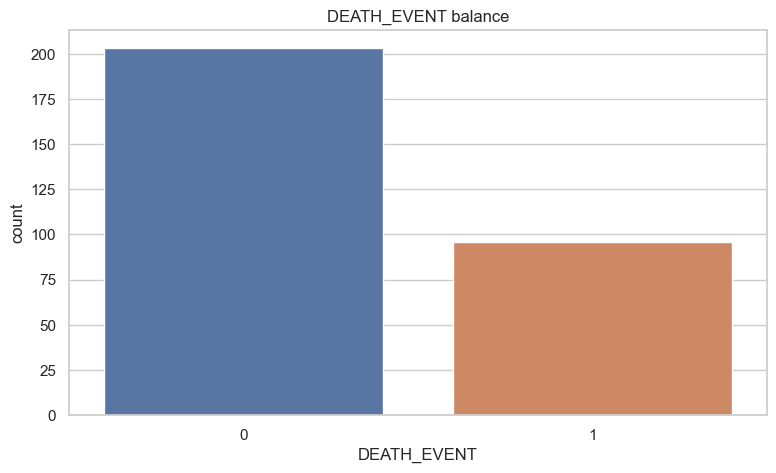

DEATH_EVENT
0    0.679
1    0.321


In [15]:
ax = sns.countplot(x="DEATH_EVENT", data=hf)
ax.set_title("DEATH_EVENT balance")
plt.show()
print(hf["DEATH_EVENT"].value_counts(normalize=True).round(3).to_string())

### 3.2 Skewed lab values

Several clinical labs are strongly right-skewed; a log1p transform makes them usable for linear/distance-based models and stabilises anomaly detection. Tree models (RF/XGB/LightGBM) are scale-invariant and don't need it, but it helps everything else and aids visual EDA.

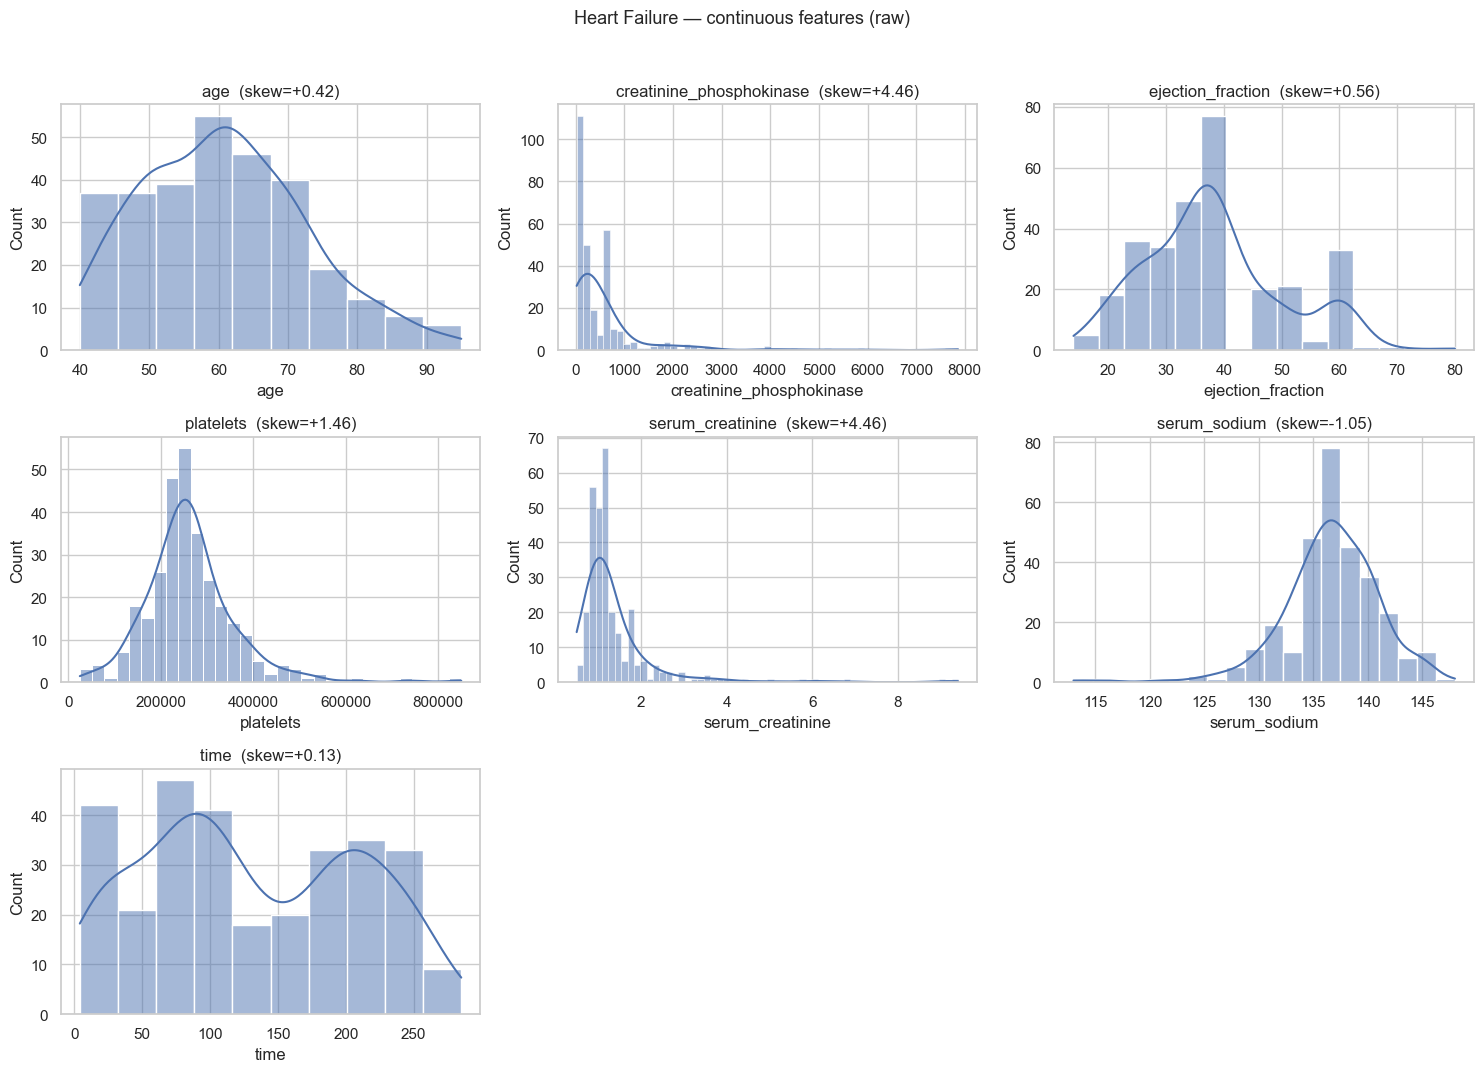

In [16]:
hf_cont = ["age", "creatinine_phosphokinase", "ejection_fraction",
           "platelets", "serum_creatinine", "serum_sodium", "time"]
plot_distributions(hf, hf_cont, title="Heart Failure — continuous features (raw)")

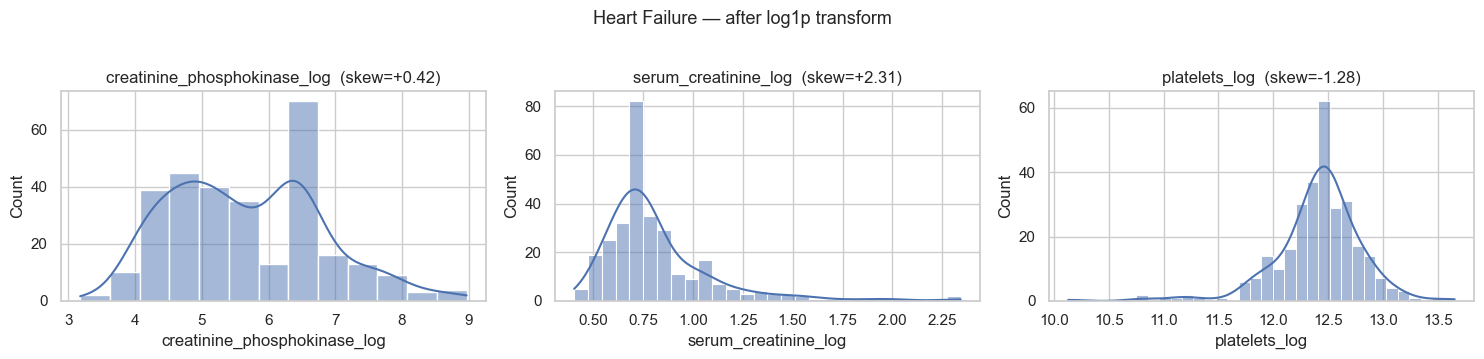

In [17]:
skewed = ["creatinine_phosphokinase", "serum_creatinine", "platelets"]
hf_log = hf.copy()
for col in skewed:
    hf_log[col + "_log"] = np.log1p(hf_log[col])
plot_distributions(hf_log, [c + "_log" for c in skewed],
                   title="Heart Failure — after log1p transform")

### 3.3 ⚠️ Leakage hazard: the `time` column

`time` is the follow-up duration in days, and it is the single strongest correlate of `DEATH_EVENT`. But that correlation is an **artefact of study design (censoring)**, not a clinical risk factor: patients with short follow-up who survived were simply censored, so short `time` co-occurs with the outcome. A model that leans on `time` will look excellent in cross-validation and fail in deployment, because at *prediction time* for a new patient you do not yet know their follow-up length.

**Recommendation for the monitoring system:** exclude `time` from the standard classifier feature set (or treat the problem as survival analysis, where `time` is the duration, not a feature). The plot below shows why it's so tempting — and so dangerous.

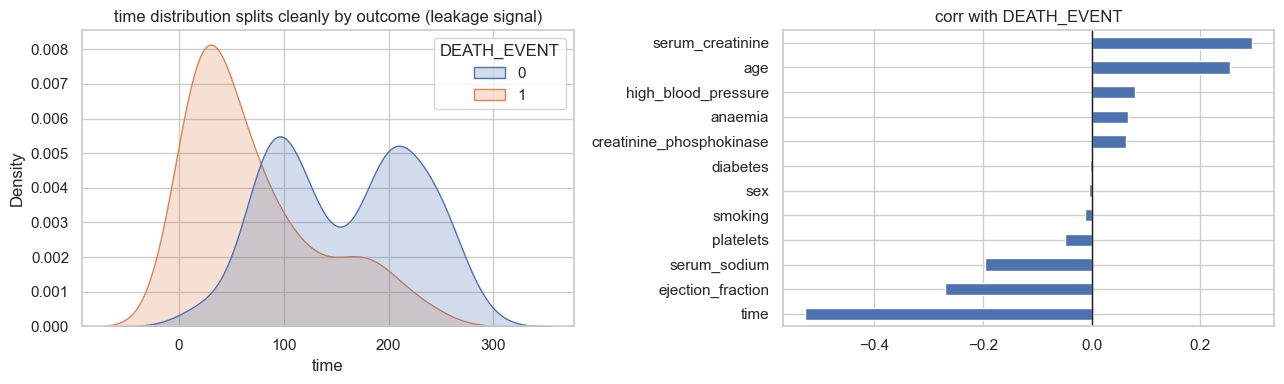

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=hf, x="time", hue="DEATH_EVENT", fill=True, common_norm=False, ax=ax[0])
ax[0].set_title("time distribution splits cleanly by outcome (leakage signal)")
hf.corr(numeric_only=True)["DEATH_EVENT"].drop("DEATH_EVENT").sort_values().plot(
    kind="barh", ax=ax[1])
ax[1].axvline(0, color="k", lw=1); ax[1].set_title("corr with DEATH_EVENT")
plt.tight_layout(); plt.show()

### 3.4 Target signal — *excluding* `time`

The legitimate clinical predictors. `serum_creatinine` (kidney function), low `ejection_fraction` (weak pumping), and `age` carry the real signal.

Target 'DEATH_EVENT' positive rate: 32.1%


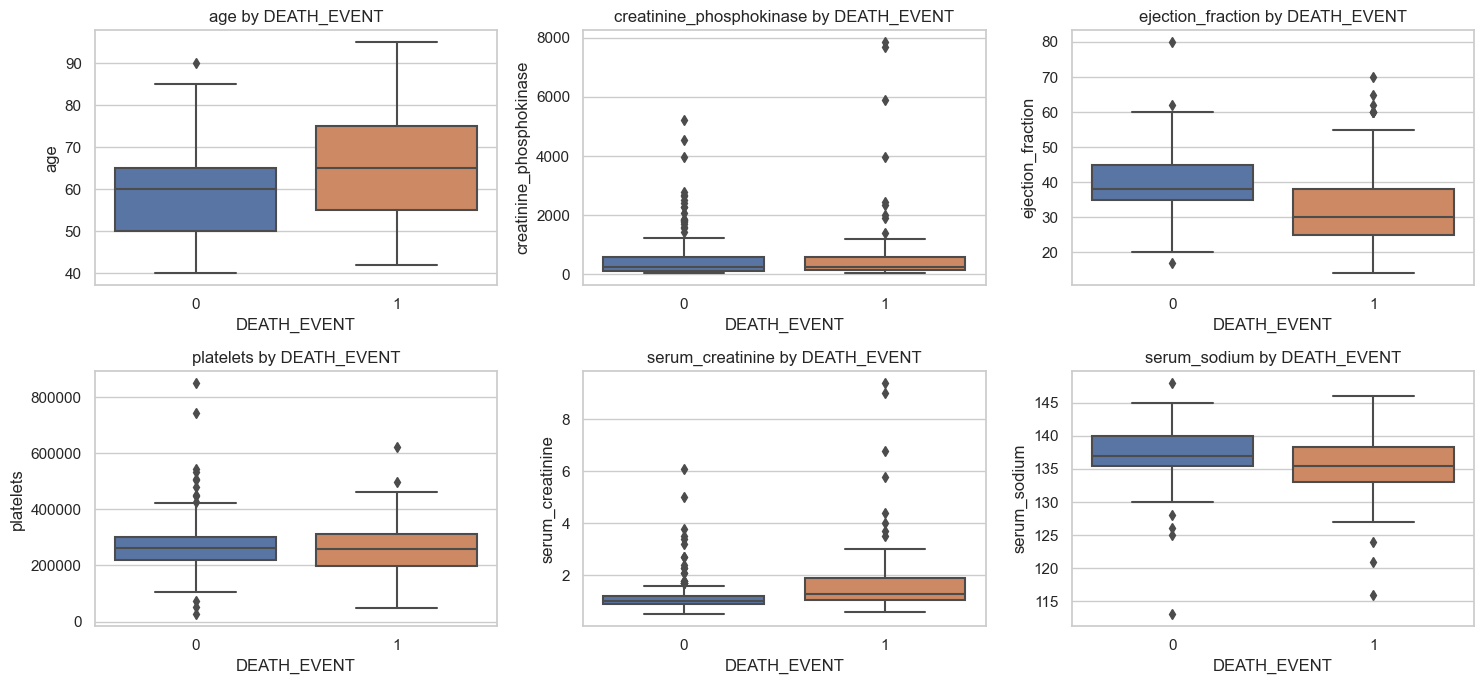

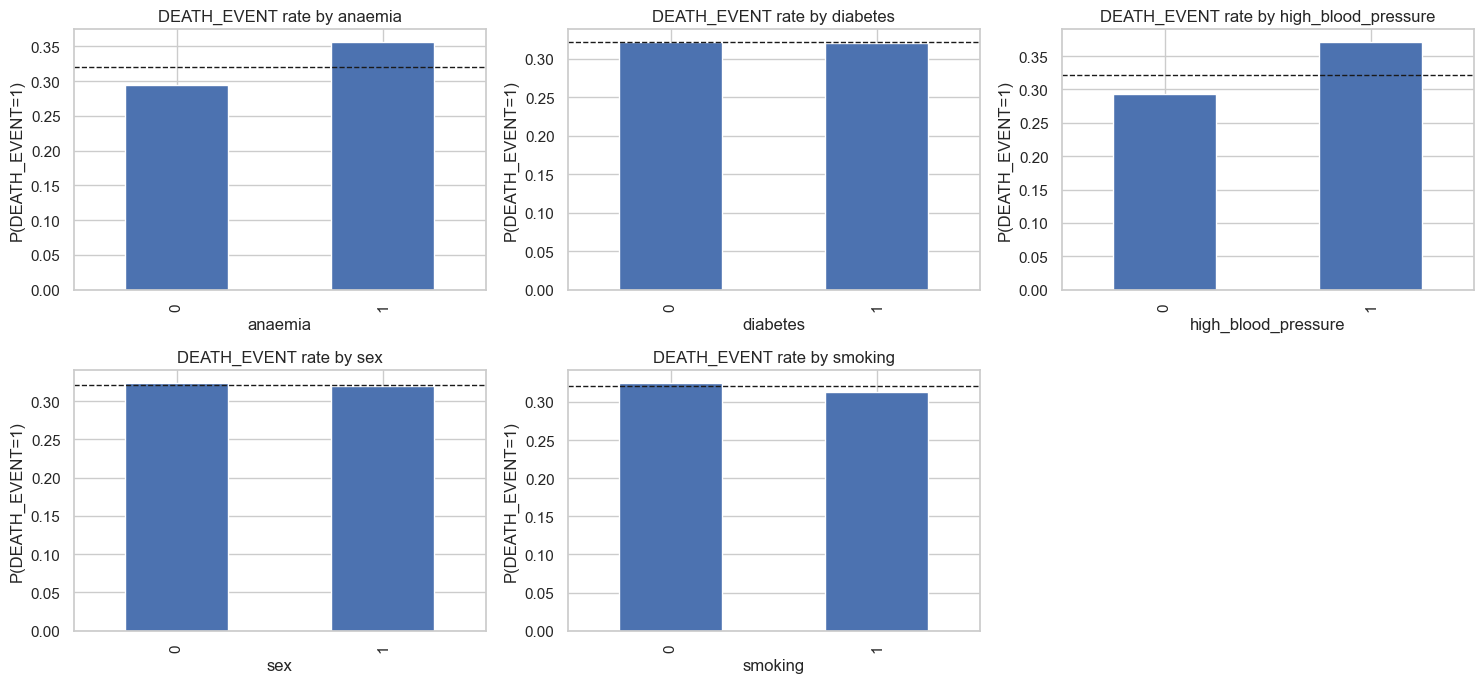

In [19]:
hf_cont_clinical = ["age", "creatinine_phosphokinase", "ejection_fraction",
                    "platelets", "serum_creatinine", "serum_sodium"]
hf_cat = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
target_analysis(hf, "DEATH_EVENT", hf_cont_clinical, hf_cat)

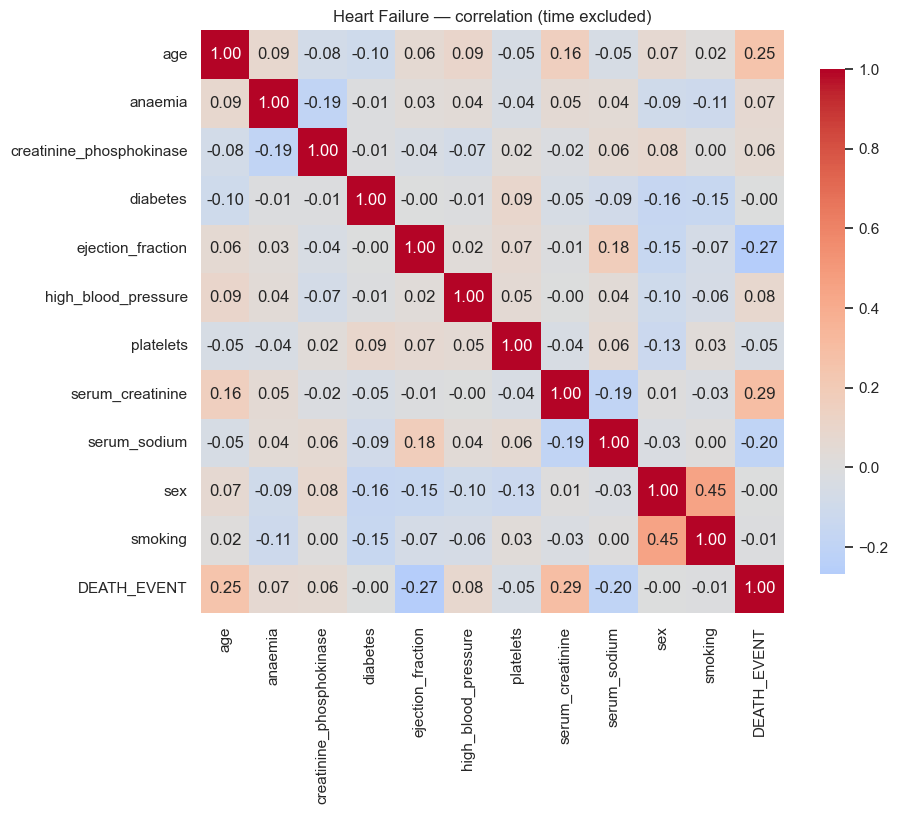

In [20]:
hf_corr = corr_heatmap(hf.drop(columns="time"),
                       "Heart Failure — correlation (time excluded)")

### 3.5 Survival framing — the principled way to *keep* `time`

3.3 showed `time` leaks the outcome when used as a plain classifier feature. The principled alternative is **survival analysis**, where `time` plays its true role — the observation duration — and `DEATH_EVENT` is the event indicator. This answers a richer clinical question: not just *whether* a patient dies, but *how survival probability evolves over time* and *which factors accelerate risk*.

Requires `lifelines` ( `pip install lifelines` ).

In [21]:
from lifelines import KaplanMeierFitter, CoxPHFitter

# --- Kaplan-Meier: overall survival, then split by reduced ejection fraction ---
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

kmf.fit(hf["time"], event_observed=hf["DEATH_EVENT"], label="all patients")
kmf.plot_survival_function(ax=ax[0])
ax[0].set_title("Overall survival"); ax[0].set_xlabel("days"); ax[0].set_ylabel("S(t)")

low_ef = hf["ejection_fraction"] < 30          # clinically "reduced" pumping
for mask, lbl in [(low_ef, "EF < 30"), (~low_ef, "EF >= 30")]:
    kmf.fit(hf.loc[mask, "time"], hf.loc[mask, "DEATH_EVENT"], label=lbl)
    kmf.plot_survival_function(ax=ax[1])
ax[1].set_title("Survival by ejection fraction"); ax[1].set_xlabel("days")
plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'lifelines'

The lower the ejection fraction, the faster the survival curve drops — a clinically expected gap that a single accuracy number would hide.

In [22]:
# --- Cox Proportional Hazards: hazard ratio for every covariate at once ---
# duration = time, event = DEATH_EVENT, everything else is a covariate.
cph = CoxPHFitter()
cph.fit(hf, duration_col="time", event_col="DEATH_EVENT")
cph.print_summary(columns=["coef", "exp(coef)", "p"])   # exp(coef) = hazard ratio

NameError: name 'CoxPHFitter' is not defined

`exp(coef)` is the **hazard ratio**: above 1 raises risk, below 1 is protective. Expect `serum_creatinine` and `age` above 1 and `ejection_fraction` below 1 — the same clinical story as the classification view, but now `time` is used correctly instead of leaking. The `p` column flags which effects are statistically reliable on these 299 patients.

In [23]:
cph.plot()
plt.title("Cox model — log(hazard ratio) per covariate (95% CI)")
plt.tight_layout(); plt.show()

NameError: name 'cph' is not defined

## 4. Cross-dataset notes & handoff to the pipeline

**Schema harmonisation (important for a unified system).** Sex/gender is encoded *inconsistently* across the project's datasets:
- `heart_disease` and `heart_failure`: `sex` → 1 = male, 0 = female
- `cardio_train`: `gender` → 1 = women, 2 = men

Any cross-dataset feature store or shared model must map these to one convention first.

**Per-dataset cleaning summary.**

| Dataset | Issue found | Action |
|---|---|---|
| Heart Disease | `ca = 4`, `thal = 0` are disguised-missing; 1 duplicate row | replace with NaN → impute (mode); drop duplicate |
| Heart Failure | imbalanced target (~32%); right-skewed labs | stratify + class weights; log1p for non-tree models |
| Heart Failure | **`time` leaks the outcome** | exclude from classifier features (or go survival) |

**Strongest legitimate predictors.** Heart disease: `cp`, `thalach`, `oldpeak`, `ca`. Heart failure: `serum_creatinine`, `ejection_fraction`, `age`.

**Two modelling bridges are included in this notebook.** 2.5 gives a **leakage-safe imputation pipeline** (sentinel-cleaning + imputation re-fit inside each CV fold) — the base every classifier should sit on. 3.5 gives a **survival-analysis framing** (Kaplan–Meier + Cox PH) that keeps `time` as the observation duration instead of leaking it.

**Next steps:** persist cleaned frames to `data/processed/`, encode categoricals, reuse the 2.5 pipeline with RF / XGBoost / LightGBM, decide per clinical goal between the classification and survival views for heart failure, and carry the leakage and harmonisation notes into the anomaly-detection stage.

> **Library note:** 2.5 uses `scikit-learn`; 3.5 uses `lifelines`. Add both to the project's `requirements.txt` (`scikit-learn`, `lifelines`).

In [24]:
out = Path("data/processed")
out.mkdir(parents=True, exist_ok=True)

hd_clean.to_csv(out / "heart_disease_clean.csv", index=False)
# drop the leakage column from the modelling-ready heart-failure frame
hf.drop(columns="time").to_csv(out / "heart_failure_clean.csv", index=False)

print("Saved:")
print(" ", out / "heart_disease_clean.csv", hd_clean.shape)
print(" ", out / "heart_failure_clean.csv", hf.drop(columns="time").shape)

Saved:
  data/processed/heart_disease_clean.csv (302, 14)
  data/processed/heart_failure_clean.csv (299, 12)
